#### Voice Description Generation with Conditioning

In [1]:
audio_descriptors = {
    "gender": ["man", "woman"],
    "noise": [
        "very noisy", "noisy", "slightly noisy", "high quality"
    ],
    "accent": [
        "american", "british", "chinese", "indian", "australian", "spanish", "french", "german", "italian", "russian", "japanese"
    ],
    "pace": [
        "very slowly", "slowly", "at a moderate speed", "fast", "very fast"
    ],
    "emotion": [
        "happy", "confused", "default", "laughing", "sad", "whisper"
    ]
}

Finds numeric digits in the string and converts them to English words.

In [2]:
from num2words import num2words
import re

def convert_digits_to_words(text):
    if not isinstance(text, str):
        return ""
    # Regex finds exact number boundaries to avoid breaking partial strings
    return re.sub(r'\b\d+\b', lambda x: num2words(int(x.group())), text)

Returns logically appropriate subsets of tone, pace, and pitch based on the energy/nature of the selected emotion.

In [3]:
import random

random.seed(42)

def generate_parler_descriptions(descriptors):
    generated_prompts = []
    for _ in range(3):
        # Select independent traits
        gender = random.choice(descriptors["gender"])
        noise = random.choice(descriptors["noise"])
        pace = random.choice(descriptors["pace"])
        accent = random.choice(descriptors["accent"])
        emotion = random.choice(descriptors["emotion"])
        # Define Natural Language Templates integrating the Emotion
        if emotion == "whisper":
            raw_prompt = f"A {accent} {gender} whispers {pace}, with {noise} audio."
        elif emotion == "default":
            raw_prompt = f"A {accent} {gender} speaks {pace}, with {noise} audio."
        elif emotion == "laughing":
            raw_prompt = f"A {accent} {gender} speaks {pace} while laughing, with {noise} audio."
        else:
            raw_prompt = f"A {accent} {gender} speaks {pace} and sounds {emotion}, with {noise} audio."
        # Clean up any weird spacing left by omitted pace/pitch strings
        clean_prompt = " ".join(raw_prompt.split()).replace(" ,", ",").replace(" .", ".")
        generated_prompts.append(clean_prompt)
    return generated_prompts

Simulating 2 different user commands

In [4]:
for i in range(2):
    print(f"--- Variations for Command {i+1} ---")
    prompts_list = generate_parler_descriptions(audio_descriptors)
    for j, prompt in enumerate(prompts_list):
        print(f"Template {j+1}: {prompt}")

--- Variations for Command 1 ---
Template 1: A indian man speaks at a moderate speed and sounds confused, with very noisy audio.
Template 2: A british man speaks very fast and sounds sad, with very noisy audio.
Template 3: A british woman speaks very slowly and sounds confused, with very noisy audio.
--- Variations for Command 2 ---
Template 1: A indian man whispers very fast, with very noisy audio.
Template 2: A russian woman speaks fast, with noisy audio.
Template 3: A spanish man speaks fast, with noisy audio.


Reads the base domotic commands from a local CSV file, and applies combinatorial voice conditioning.

In [5]:
import pandas as pd
import csv
import os

def create_prompts_dataset(input_csv, output_csv):
    try:
        df_base = pd.read_csv(input_csv)
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}.")
        return

    output_rows = []
    # Iterate through the dataframe using the explicit row index as the cmd_id
    for cmd_id, row in df_base.iterrows():
        user_command = row.get("User_Command", "")
        # Skip empty rows
        if not isinstance(user_command, str) or not user_command.strip():
            continue
        # Convert numeric digits to textual words
        user_command = convert_digits_to_words(user_command)
        # Generate the 3 unique description prompts
        prompts_list = generate_parler_descriptions(audio_descriptors)
        # Append 3 separate rows linking back to the same cmd_idx
        for prompt in prompts_list:
            output_rows.append({
                "cmd_id": cmd_id,
                "User_Command": user_command, # Included for easier debugging/tracking
                "Voice_Description": prompt
            })
    os.makedirs("./data", exist_ok=True)
    df_output = pd.DataFrame(output_rows)
    df_output.index.name = "prompt_id"
    df_output.to_csv(
        output_csv,
        index=True,
        quoting=csv.QUOTE_ALL,
        escapechar='\\'
    )

In [6]:
create_prompts_dataset("./data/cleaned_raw_train.csv", "./data/description_prompts_train.csv")
create_prompts_dataset("./data/cleaned_raw_test.csv", "./data/description_prompts_test.csv")

#### Dataset Evaluation & Visualization

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def extract_traits(prompt, category_vocab):
    # Sort vocabulary by length descending so longer phrases are matched first
    # (e.g., checks "woman" before "man", and "very noisy" before "noisy")
    sorted_vocab = sorted(category_vocab, key=len, reverse=True)
    for trait in sorted_vocab:
        trait = "whispers" if trait == "whisper" else trait
        if trait == "default":
            continue
        # Use regex with word boundaries (\b) to match exact words, ignoring case
        # This ensures 'man' does not trigger inside 'woman'
        pattern = r'\b' + re.escape(trait) + r'\b'
        if re.search(pattern, str(prompt), re.IGNORECASE):
            return trait
    if "default" in category_vocab:
        return "default"
    return "Unknown"

# 2. Evaluation Logic & Distribution Parsing
def evaluate_dataset_diversity(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}. Please run the generation script first.")
        return None

    # Extract traits back out of the natural language strings
    for category, vocab in audio_descriptors.items():
        df[category] = df["Voice_Description"].apply(lambda x: extract_traits(x, vocab))
    # 3. Statistical Variance Check
    # To prove "near-uniform distribution", we calculate the Coefficient of Variation (CV).
    # A low CV (< 0.15) mathematically proves that no single trait dominates the dataset.
    print("--- Statistical Distribution Proof (Target: Near-Uniform) ---")
    for category in audio_descriptors.keys():
        counts = df[category].value_counts()
        mean_freq = counts.mean()
        std_freq = counts.std() if len(counts) > 1 else 0
        cv = std_freq / mean_freq if mean_freq > 0 else 0
        print(f"{category.upper()}:")
        print(f"  - Unique Categories Found: {len(counts)}")
        print(f"  - Mean Samples per Category: {mean_freq:.1f}")
        print(f"  - Coefficient of Variation (CV): {cv:.3f} " + ("(Perfectly Balanced)" if cv < 0.15 else "(High Variance)"))
    return df

def plot_dataset_diversity(df):
    if df is None or df.empty:
        print("Error: Invalid DataFrame provided for plotting.")
        return

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Acoustic Trait Distribution Analysis', fontsize=18, fontweight='bold', y=0.98)

    # Plot 1: Gender
    gender_counts = df["gender"].value_counts()
    axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
    axes[0, 0].set_title('Speaker Gender Distribution', fontsize=14, fontweight='bold')

    # Plot 2: Emotion
    sns.countplot(data=df, y="emotion", ax=axes[0, 1], order=df["emotion"].value_counts().index, palette="viridis", hue="emotion", legend=False)
    axes[0, 1].set_title('Injected Emotional States', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Number of Prompts')
    axes[0, 1].set_ylabel('')

    # Plot 3: Accent
    sns.countplot(data=df, y="accent", ax=axes[1, 0], order=df["accent"].value_counts().index, palette="magma", hue="accent", legend=False)
    axes[1, 0].set_title('Speaker Accent Diversity', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Prompts')
    axes[1, 0].set_ylabel('')

    # Plot 4: Noise
    sns.countplot(data=df, y="noise", ax=axes[1, 1], order=df["noise"].value_counts().index, palette="coolwarm", hue="noise", legend=False)
    axes[1, 1].set_title('Channel Noise Conditions', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Prompts')
    axes[1, 1].set_ylabel('')

    # Plot 5: Pace
    sns.countplot(data=df, y="pace", ax=axes[2, 0], order=df["pace"].value_counts().index, palette="crest", hue="pace", legend=False)
    axes[2, 0].set_title('Speech Pace', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('Number of Prompts')
    axes[2, 0].set_ylabel('')

    # Hide the final empty subplot (bottom right) since we only have 5 traits
    axes[2, 1].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

--- Statistical Distribution Proof (Target: Near-Uniform) ---
GENDER:
  - Unique Categories Found: 2
  - Mean Samples per Category: 20148.0
  - Coefficient of Variation (CV): 0.003 (Perfectly Balanced)
NOISE:
  - Unique Categories Found: 4
  - Mean Samples per Category: 10074.0
  - Coefficient of Variation (CV): 0.014 (Perfectly Balanced)
ACCENT:
  - Unique Categories Found: 11
  - Mean Samples per Category: 3663.3
  - Coefficient of Variation (CV): 0.016 (Perfectly Balanced)
PACE:
  - Unique Categories Found: 5
  - Mean Samples per Category: 8059.2
  - Coefficient of Variation (CV): 0.006 (Perfectly Balanced)
EMOTION:
  - Unique Categories Found: 6
  - Mean Samples per Category: 6716.0
  - Coefficient of Variation (CV): 0.007 (Perfectly Balanced)


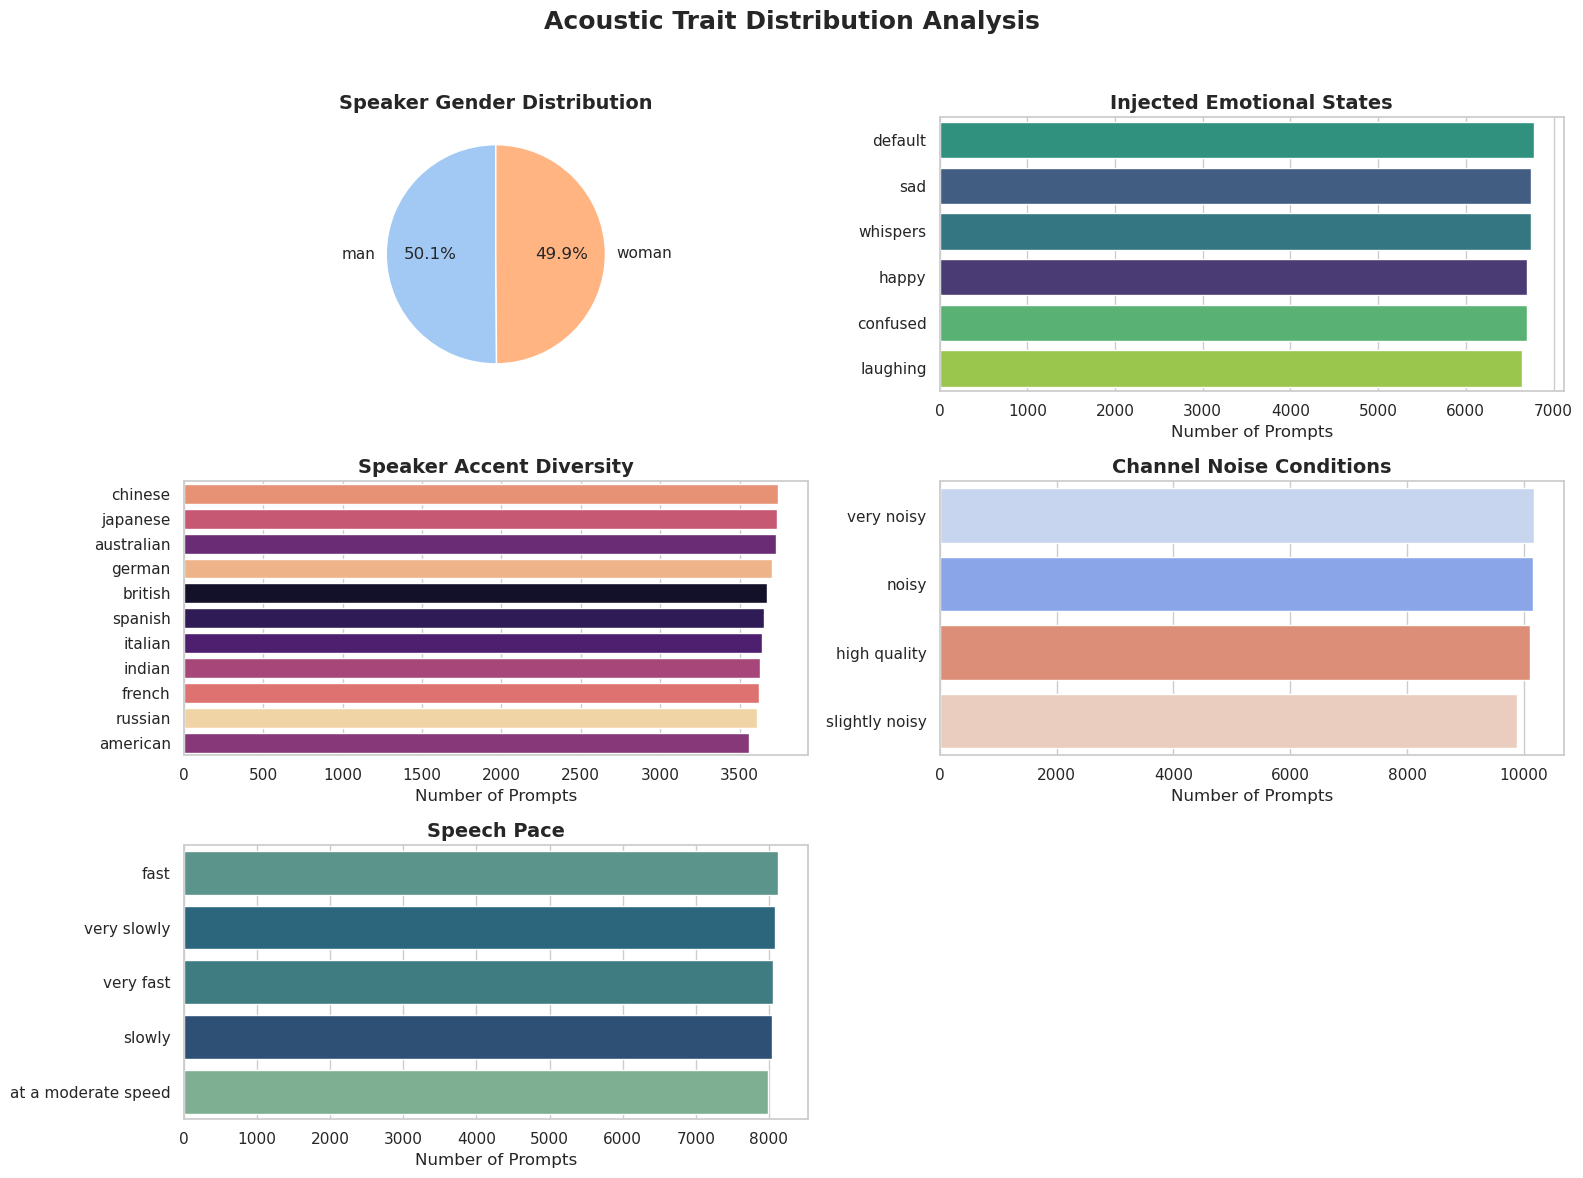

In [15]:
plot_dataset_diversity(evaluate_dataset_diversity("./data/description_prompts_train.csv"))

--- Statistical Distribution Proof (Target: Near-Uniform) ---
GENDER:
  - Unique Categories Found: 2
  - Mean Samples per Category: 5325.0
  - Coefficient of Variation (CV): 0.016 (Perfectly Balanced)
NOISE:
  - Unique Categories Found: 4
  - Mean Samples per Category: 2662.5
  - Coefficient of Variation (CV): 0.010 (Perfectly Balanced)
ACCENT:
  - Unique Categories Found: 11
  - Mean Samples per Category: 968.2
  - Coefficient of Variation (CV): 0.034 (Perfectly Balanced)
PACE:
  - Unique Categories Found: 5
  - Mean Samples per Category: 2130.0
  - Coefficient of Variation (CV): 0.034 (Perfectly Balanced)
EMOTION:
  - Unique Categories Found: 6
  - Mean Samples per Category: 1775.0
  - Coefficient of Variation (CV): 0.033 (Perfectly Balanced)


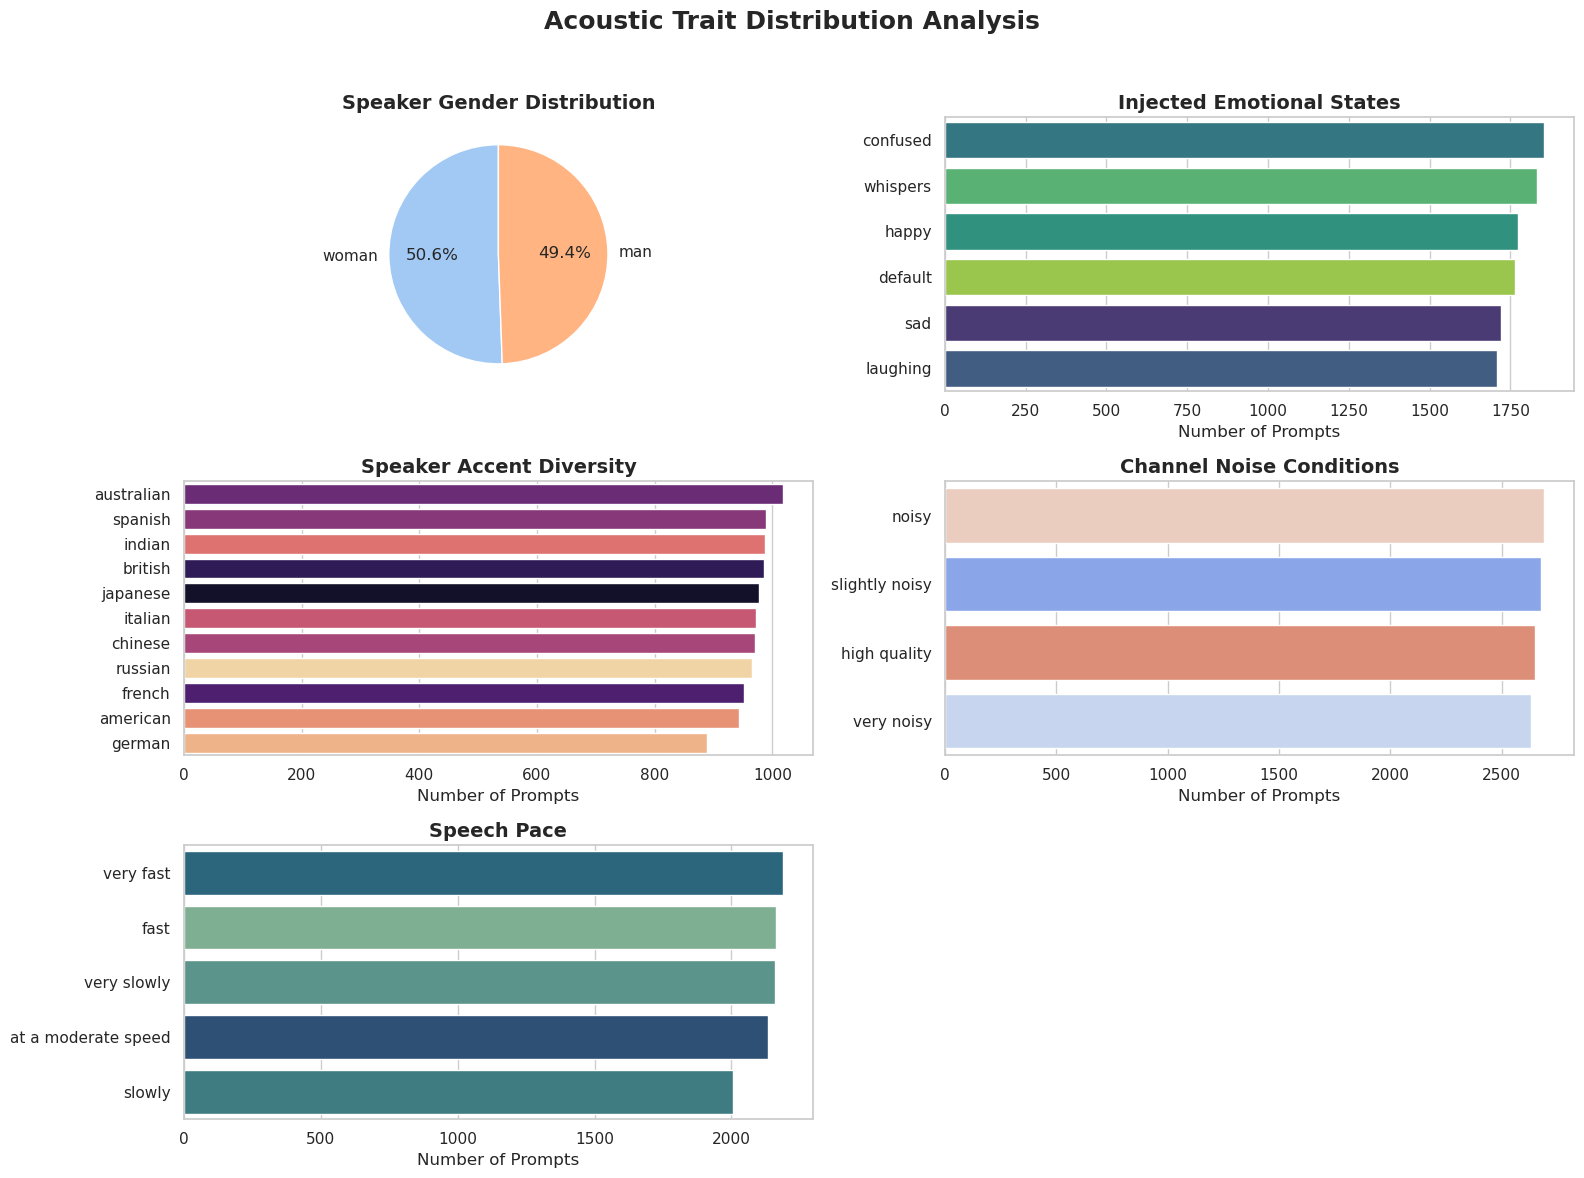

In [16]:
plot_dataset_diversity(evaluate_dataset_diversity("./data/description_prompts_test.csv"))